In [1]:
import pandas as pd
import numpy as np

In [2]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [6]:
# Calculate Historical VaR and CVaR for all funds

var_cvar = (
    nav
    .groupby("amfi_code")["daily_return"]
    .agg(
        VaR_95=lambda x: x.quantile(0.05),
        CVaR_95=lambda x: x[x <= x.quantile(0.05)].mean()
    )
    .reset_index()
)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [7]:
var_cvar.to_csv("var_cvar_report.csv", index=False)

print("VaR and CVaR report saved successfully!")

VaR and CVaR report saved successfully!


In [8]:
# Calculate 90-day rolling Sharpe ratio

nav["rolling_sharpe_90d"] = (
    nav.groupby("amfi_code")["daily_return"]
       .transform(
           lambda x: x.rolling(90).mean() /
                     x.rolling(90).std()
       )
)

nav[["amfi_code", "date", "rolling_sharpe_90d"]].tail()

,amfi_code,date,rolling_sharpe_90d
45995,149324,2026-05-25,0.128684
45996,149324,2026-05-26,0.130080
45997,149324,2026-05-27,0.123005
45998,149324,2026-05-28,0.088585
45999,149324,2026-05-29,0.079547


In [9]:
rolling_sharpe = nav[
    ["amfi_code", "date", "rolling_sharpe_90d"]
].dropna()

rolling_sharpe.to_csv(
    "rolling_90d_sharpe.csv",
    index=False
)

print("90-day rolling Sharpe report saved successfully!")

90-day rolling Sharpe report saved successfully!


In [10]:
transactions.columns

NameError: name 'transactions' is not defined

In [11]:
import os

os.listdir("../data/processed")

['alpha_beta.csv',
 'fund_scorecard.csv',
 'investor_transactions_cleaned.csv',
 'investor_transactions_cleaned.xlsx',
 'nav_history_cleaned.csv',
 'scheme_performance_cleaned.csv']

In [12]:
transactions = pd.read_csv(
    "../data/processed/investor_transactions_cleaned.csv"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [13]:
# Convert transaction date to datetime
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

# Find each investor's first transaction date
first_transaction = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

# Create cohort year
first_transaction["cohort_year"] = (
    first_transaction["transaction_date"].dt.year
)

first_transaction.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [14]:
# Add cohort year to every transaction
transactions = transactions.merge(
    first_transaction[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

# Create cohort summary
cohort_analysis = (
    transactions
    .groupby("cohort_year")
    .agg(
        investors=("investor_id", "nunique"),
        total_investment=("amount_inr", "sum"),
        average_investment=("amount_inr", "mean"),
        transactions=("investor_id", "count")
    )
    .reset_index()
)

cohort_analysis

,cohort_year,investors,total_investment,average_investment,transactions
0,2024,4803,3491125187,107422.541832,32499
1,2025,197,30455243,109158.577061,279


In [16]:
cohort_analysis.to_csv(
    "investor_cohort_analysis.csv",
    index=False
)

print("Investor cohort analysis saved successfully!")


Investor cohort analysis saved successfully!


In [17]:
transactions["transaction_type"].value_counts()

transaction_type
Sip           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [18]:
# Keep only SIP transactions
sip_transactions = transactions[
    transactions["transaction_type"] == "Sip"
].copy()

# Convert date to month
sip_transactions["sip_month"] = (
    sip_transactions["transaction_date"]
    .dt.to_period("M")
)

# Count unique SIP months for each investor
sip_continuity = (
    sip_transactions
    .groupby("investor_id")["sip_month"]
    .nunique()
    .reset_index(name="sip_months")
)

sip_continuity.head()

,investor_id,sip_months
0,INV000001,2
1,INV000002,3
2,INV000003,2
3,INV000004,6
4,INV000005,2


In [19]:
sip_continuity["continuity"] = pd.cut(
    sip_continuity["sip_months"],
    bins=[0, 3, 6, 9, 12, float("inf")],
    labels=[
        "Low",
        "Moderate",
        "Good",
        "Very Good",
        "Excellent"
    ]
)

sip_continuity.head()

,investor_id,sip_months,continuity
0,INV000001,2,Low
1,INV000002,3,Low
2,INV000003,2,Low
3,INV000004,6,Moderate
4,INV000005,2,Low


In [20]:
sip_continuity_summary = (
    sip_continuity
    .groupby("continuity", observed=False)
    .agg(
        investors=("investor_id", "nunique"),
        average_sip_months=("sip_months", "mean")
    )
    .reset_index()
)

sip_continuity_summary

,continuity,investors,average_sip_months
0,Low,2360,2.015678
1,Moderate,2030,4.850246
2,Good,368,7.347826
3,Very Good,4,10.000000
4,Excellent,0,NaN


In [21]:
sip_continuity_summary.to_csv(
    "sip_continuity_analysis.csv",
    index=False
)

print("SIP continuity analysis saved successfully!")

SIP continuity analysis saved successfully!


In [22]:
fund_scorecard = pd.read_csv(
    "../data/processed/fund_scorecard.csv"
)

fund_scorecard.head()

,Fund,CAGR,Sharpe Ratio,Sortino Ratio,Max Drawdown
0,118632,15.16,0.56,0.70,-39.96
1,119092,50.67,0.26,656.94,-1.39
2,119551,0.25,-0.67,-0.38,-36.65
3,120503,15.70,NaN,inf,-100.00
4,120841,16.73,0.68,0.80,-33.43


In [23]:
fund_scorecard.columns

Index(['Fund', 'CAGR', 'Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown'], dtype='object')

In [24]:
# Make sure performance columns are numeric

metrics = ["CAGR", "Sharpe Ratio", "Sortino Ratio", "Max Drawdown"]

for col in metrics:
    fund_scorecard[col] = pd.to_numeric(
        fund_scorecard[col],
        errors="coerce"
    )

fund_scorecard.head()

,Fund,CAGR,Sharpe Ratio,Sortino Ratio,Max Drawdown
0,118632,15.16,0.56,0.70,-39.96
1,119092,50.67,0.26,656.94,-1.39
2,119551,0.25,-0.67,-0.38,-36.65
3,120503,15.70,NaN,inf,-100.00
4,120841,16.73,0.68,0.80,-33.43


In [26]:
# Replace infinity values with NaN
fund_scorecard = fund_scorecard.replace(
    [np.inf, -np.inf],
    np.nan
)

# Check how many missing values we have
fund_scorecard[
    ["CAGR", "Sharpe Ratio", "Sortino Ratio", "Max Drawdown"]
].isna().sum()

CAGR             0
Sharpe Ratio     1
Sortino Ratio    1
Max Drawdown     0
dtype: int64

In [27]:
score_data = fund_scorecard.dropna(
    subset=[
        "CAGR",
        "Sharpe Ratio",
        "Sortino Ratio",
        "Max Drawdown"
    ]
).copy()

print("Funds available for recommendation:", len(score_data))

Funds available for recommendation: 5


In [28]:
fund_scorecard[
    ["Fund", "CAGR", "Sharpe Ratio", "Sortino Ratio", "Max Drawdown"]
].isna().sum()

Fund             0
CAGR             0
Sharpe Ratio     1
Sortino Ratio    1
Max Drawdown     0
dtype: int64

In [29]:
fund_scorecard[
    ["Fund", "CAGR", "Sharpe Ratio", "Sortino Ratio", "Max Drawdown"]
].head(40)

,Fund,CAGR,Sharpe Ratio,Sortino Ratio,Max Drawdown
0,118632,15.16,0.56,0.70,-39.96
1,119092,50.67,0.26,656.94,-1.39
2,119551,0.25,-0.67,-0.38,-36.65
3,120503,15.70,NaN,NaN,-100.00
4,120841,16.73,0.68,0.80,-33.43
5,125497,24.25,1.11,1.35,-40.26


In [30]:
# Calculate Sharpe and Sortino for fund 120503 from NAV returns

fund_120503 = nav[
    nav["amfi_code"] == 120503
].copy()

returns_120503 = fund_120503["daily_return"].dropna()

sharpe_120503 = (
    returns_120503.mean() / returns_120503.std()
)

downside_returns = returns_120503[
    returns_120503 < 0
]

sortino_120503 = (
    returns_120503.mean() / downside_returns.std()
)

print("Sharpe Ratio:", sharpe_120503)
print("Sortino Ratio:", sortino_120503)

Sharpe Ratio: 0.0797582457930729
Sortino Ratio: 0.13372885740338272


In [31]:
# Fill the missing metrics for fund 120503

fund_scorecard.loc[
    fund_scorecard["Fund"] == 120503,
    "Sharpe Ratio"
] = sharpe_120503

fund_scorecard.loc[
    fund_scorecard["Fund"] == 120503,
    "Sortino Ratio"
] = sortino_120503

print(
    fund_scorecard[
        fund_scorecard["Fund"] == 120503
    ]
)

     Fund  CAGR  Sharpe Ratio  Sortino Ratio  Max Drawdown
3  120503  15.7      0.079758       0.133729        -100.0


In [32]:
score_data = fund_scorecard.copy()

# Remove any remaining infinite values
score_data = score_data.replace(
    [np.inf, -np.inf],
    np.nan
)

# Keep only funds with complete metrics
score_data = score_data.dropna(
    subset=[
        "CAGR",
        "Sharpe Ratio",
        "Sortino Ratio",
        "Max Drawdown"
    ]
).copy()

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

score_data[
    [
        "CAGR_score",
        "Sharpe_score",
        "Sortino_score",
        "Drawdown_score"
    ]
] = scaler.fit_transform(
    score_data[
        [
            "CAGR",
            "Sharpe Ratio",
            "Sortino Ratio",
            "Max Drawdown"
        ]
    ]
)

score_data["Recommendation_Score"] = (
    score_data["CAGR_score"] * 0.25
    + score_data["Sharpe_score"] * 0.25
    + score_data["Sortino_score"] * 0.25
    + score_data["Drawdown_score"] * 0.25
)

score_data = score_data.sort_values(
    "Recommendation_Score",
    ascending=False
)

score_data[
    [
        "Fund",
        "CAGR",
        "Sharpe Ratio",
        "Sortino Ratio",
        "Max Drawdown",
        "Recommendation_Score"
    ]
]

,Fund,CAGR,Sharpe Ratio,Sortino Ratio,Max Drawdown,Recommendation_Score
1,119092,50.67,0.260000,656.940000,-1.39,0.880618
5,125497,24.25,1.110000,1.350000,-40.26,0.521114
4,120841,16.73,0.680000,0.800000,-33.43,0.440540
0,118632,15.16,0.560000,0.700000,-39.96,0.399308
3,120503,15.70,0.079758,0.133729,-100.00,0.182105
2,119551,0.25,-0.670000,-0.380000,-36.65,0.160607


In [33]:
recommendation = score_data[
    [
        "Fund",
        "CAGR",
        "Sharpe Ratio",
        "Sortino Ratio",
        "Max Drawdown",
        "Recommendation_Score"
    ]
]

recommendation.to_csv(
    "fund_recommendations.csv",
    index=False
)

print("Fund recommendation report saved successfully!")

Fund recommendation report saved successfully!


In [34]:
import os

os.listdir("../data/processed")

['alpha_beta.csv',
 'fund_scorecard.csv',
 'investor_transactions_cleaned.csv',
 'investor_transactions_cleaned.xlsx',
 'nav_history_cleaned.csv',
 'scheme_performance_cleaned.csv']

In [35]:
scheme_performance = pd.read_csv(
    "../data/processed/scheme_performance_cleaned.csv"
)

scheme_performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [36]:
# Load investor transactions
transactions = pd.read_csv(
    "../data/processed/investor_transactions_cleaned.csv"
)

# Merge transactions with scheme category
hhi_data = transactions.merge(
    scheme_performance[['amfi_code', 'category']],
    on='amfi_code',
    how='left'
)

# Check the result
hhi_data[['amfi_code', 'amount_inr', 'category']].head()

,amfi_code,amount_inr,category
0,119092,1834,Large Cap
1,148567,392882,Large Cap
2,118636,912,Gilt
3,118634,1102,Small Cap
4,119094,8682,Mid Cap


In [37]:
hhi_data['category'].isna().sum()

0

In [38]:
# Calculate total investment by category
category_investment = (
    hhi_data.groupby('category')['amount_inr']
    .sum()
    .sort_values(ascending=False)
)

# Calculate percentage share of each category
category_share = category_investment / category_investment.sum()

# Calculate HHI
hhi = (category_share ** 2).sum()

print("Investment by Category:")
print(category_investment)

print("\nCategory Share:")
print(category_share)

print("\nHHI:", hhi)

Investment by Category:
category
Large Cap          1191688743
Mid Cap             625131734
Small Cap           518893799
Liquid              272053840
Flexi Cap           181819717
Gilt                181229634
Index               100374918
Large & Mid Cap      99482585
Value                93475766
Short Duration       92212042
Index/ETF            84420621
ELSS                 80797031
Name: amount_inr, dtype: int64

Category Share:
category
Large Cap          0.338396
Mid Cap            0.177515
Small Cap          0.147347
Liquid             0.077253
Flexi Cap          0.051630
Gilt               0.051463
Index              0.028503
Large & Mid Cap    0.028249
Value              0.026544
Short Duration     0.026185
Index/ETF          0.023972
ELSS               0.022943
Name: amount_inr, dtype: float64

HHI: 0.18311823820355144


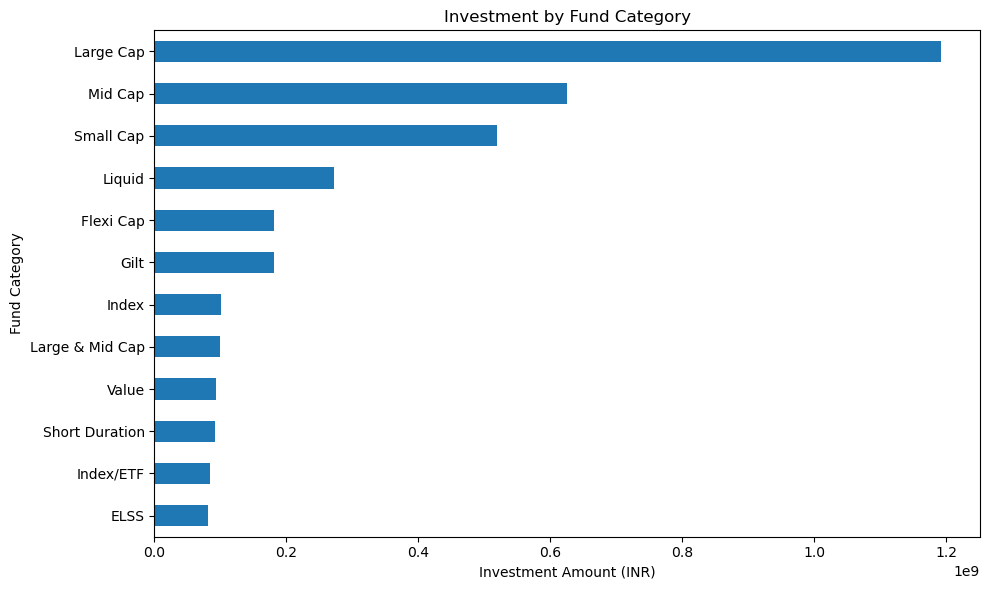

In [39]:
import matplotlib.pyplot as plt

# Category investment chart
plt.figure(figsize=(10, 6))

category_investment.sort_values().plot(kind='barh')

plt.title('Investment by Fund Category')
plt.xlabel('Investment Amount (INR)')
plt.ylabel('Fund Category')
plt.tight_layout()

plt.show()

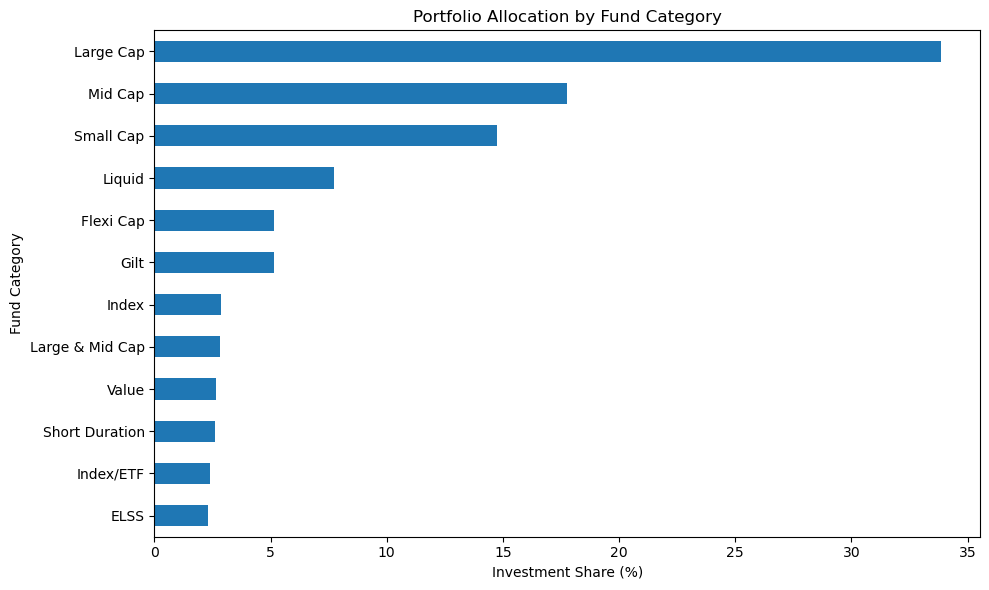

In [40]:
plt.figure(figsize=(10, 6))

(category_share * 100).sort_values().plot(kind='barh')

plt.title('Portfolio Allocation by Fund Category')
plt.xlabel('Investment Share (%)')
plt.ylabel('Fund Category')
plt.tight_layout()

plt.show()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

recommendation = pd.read_csv("fund_recommendations.csv")

recommendation.head()

,Fund,CAGR,Sharpe Ratio,Sortino Ratio,Max Drawdown,Recommendation_Score
0,119092,50.67,0.260000,656.940000,-1.39,0.880618
1,125497,24.25,1.110000,1.350000,-40.26,0.521114
2,120841,16.73,0.680000,0.800000,-33.43,0.440540
3,118632,15.16,0.560000,0.700000,-39.96,0.399308
4,120503,15.70,0.079758,0.133729,-100.00,0.182105


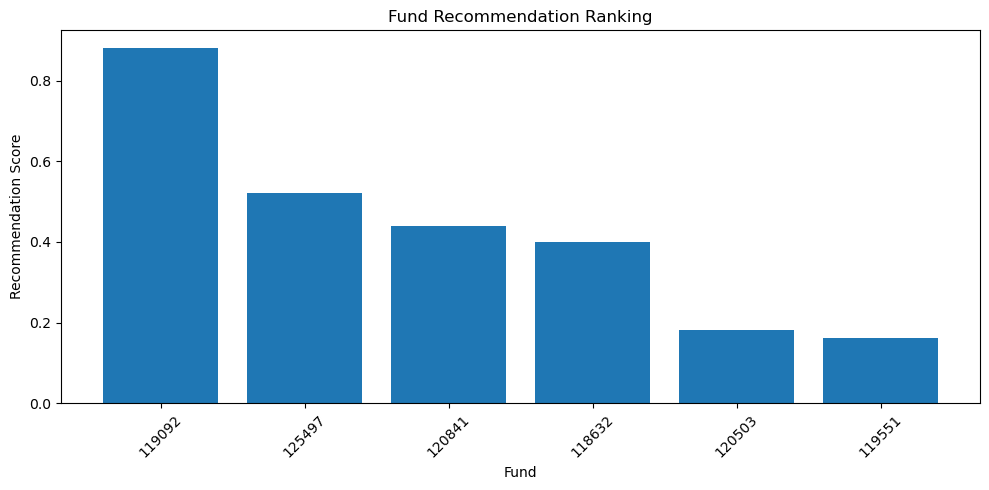

In [5]:
import matplotlib.pyplot as plt

top_funds = recommendation.sort_values(
    "Recommendation_Score",
    ascending=False
)

plt.figure(figsize=(10, 5))
plt.bar(
    top_funds["Fund"].astype(str),
    top_funds["Recommendation_Score"]
)
plt.xlabel("Fund")
plt.ylabel("Recommendation Score")
plt.title("Fund Recommendation Ranking")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

sip_continuity_summary = pd.read_csv(
    "sip_continuity_analysis.csv"
)

sip_continuity_summary

,continuity,investors,average_sip_months
0,Low,2360,2.015678
1,Moderate,2030,4.850246
2,Good,368,7.347826
3,Very Good,4,10.000000
4,Excellent,0,NaN


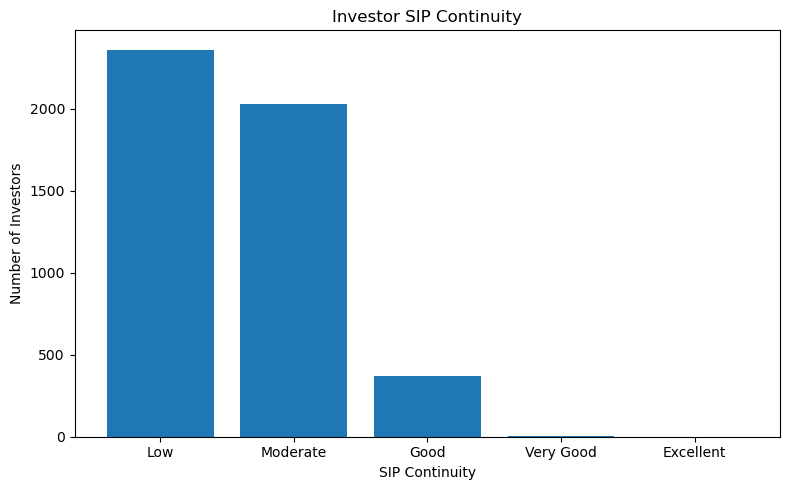

In [7]:
plt.figure(figsize=(8, 5))

plt.bar(
    sip_continuity_summary["continuity"].astype(str),
    sip_continuity_summary["investors"]
)

plt.xlabel("SIP Continuity")
plt.ylabel("Number of Investors")
plt.title("Investor SIP Continuity")

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

var_cvar = pd.read_csv("var_cvar_report.csv")

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


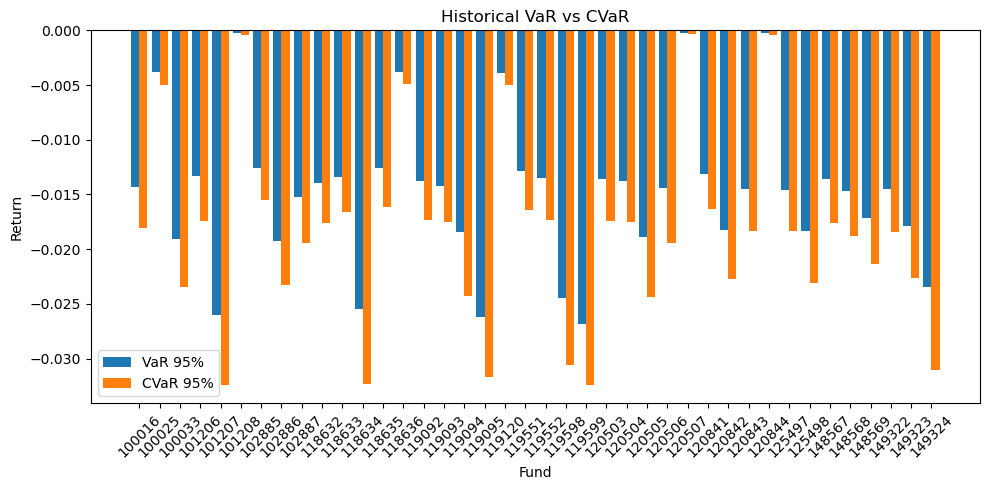

In [9]:
plt.figure(figsize=(10, 5))

x = range(len(var_cvar))

plt.bar(
    [i - 0.2 for i in x],
    var_cvar["VaR_95"],
    width=0.4,
    label="VaR 95%"
)

plt.bar(
    [i + 0.2 for i in x],
    var_cvar["CVaR_95"],
    width=0.4,
    label="CVaR 95%"
)

plt.xlabel("Fund")
plt.ylabel("Return")
plt.title("Historical VaR vs CVaR")
plt.xticks(
    x,
    var_cvar["amfi_code"].astype(str),
    rotation=45
)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd

category_files = [
    "category_investment_analysis.csv",
    "category_allocation.csv"
]

for file in category_files:
    try:
        category_data = pd.read_csv(file)
        print("Loaded:", file)
        print(category_data.head())
        break
    except FileNotFoundError:
        pass

In [11]:
import os

[x for x in os.listdir() if x.endswith(".csv")]

['fund_recommendations.csv',
 'investor_cohort_analysis.csv',
 'rolling_90d_sharpe.csv',
 'sip_continuity_analysis.csv',
 'var_cvar_report.csv']

In [12]:
[name for name in globals() if "categor" in name.lower() or "hhi" in name.lower()]

['category_files']

In [13]:
category_files

['category_investment_analysis.csv', 'category_allocation.csv']

In [15]:
import os

matches = []

for root, dirs, files in os.walk(".."):
    for file in files:
        if file in ["category_allocation.csv", "category_investment_analysis.csv"]:
            matches.append(os.path.join(root, file))

matches

[]